# TCN-MLP (Lightweight - 9 Climate Features) - Training and Evaluation

**Lightweight model using 9 core climate features**:
- Temperature: T2M, T2M_MAX, T2M_MIN, TS
- Precipitation: PRECTOTCORR
- Humidity: RH2M, QV2M, T2MDEW, T2MWET

**Enhancements**:
- Focused feature set (9 critical climate variables)
- Seasonal feature engineering
- Lightweight TCN-MLP architecture
- Better regularization & hyperparameters
- Stratified sampling by crop

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, Model, Input, optimizers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version: {tf.__version__}')
print('Seed set to 42')

TensorFlow version: 2.20.0
Seed set to 42


## 1) Load Data and Derive T2M_AVG

In [2]:
DATA_PATH = '../data/processed_dataset.csv'
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['Yield_kg_per_ha']).copy()

# Derive monthly average temperature from max/min temperature
for month in range(1, 13):
    max_col = f'T2M_MAX_m{month}'
    min_col = f'T2M_MIN_m{month}'
    out_col = f'T2M_AVG_m{month}'
    if max_col in df.columns and min_col in df.columns:
        df[out_col] = (df[max_col] + df[min_col]) / 2.0

print('Dataset shape:', df.shape)
print('Years:', int(df['Year'].min()), '-', int(df['Year'].max()))
print('Crops:', sorted(df['Crop'].unique()))
print('Regions:', sorted(df['Region'].unique()))

Dataset shape: (600, 220)
Years: 1999 - 2023
Crops: ['Cassava', 'Maize', 'Rice', 'Yam']
Regions: ['North-Central', 'North-East', 'North-West', 'South-East', 'South-South', 'South-West']


## 2) Build Climate Sequences (9 Climate Features) with Seasonal Engineering

In [3]:
# Define 9 core climate features (lightweight)
climate_features = [
    'T2M',            # Mean temperature (computed from max/min)
    'T2M_MAX',        # Max temperature
    'T2M_MIN',        # Min temperature
    'TS',             # Surface temperature
    'T2MDEW',         # Dew point temperature
    'T2MWET',         # Wet bulb temperature
    'PRECTOTCORR',    # Bias-corrected precipitation
    'RH2M',           # Relative humidity at 2m
    'QV2M',           # Specific humidity at 2m
]

n_features = len(climate_features)
n_months = 12

# Validate all required columns exist
missing_cols = []
for m in range(1, n_months + 1):
    for feat in climate_features:
        c = f'{feat}_m{m}'
        if c not in df.columns:
            missing_cols.append(c)

if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols[:10]} ... total={len(missing_cols)}')

# Build 3D sequence array: (samples, months, features)
X_seq = np.zeros((df.shape[0], n_months, n_features), dtype=np.float32)
for m in range(1, n_months + 1):
    for i, feat in enumerate(climate_features):
        X_seq[:, m - 1, i] = df[f'{feat}_m{m}'].values

y_raw = df['Yield_kg_per_ha'].values.astype(np.float32)
years = df['Year'].values.astype(np.float32)

region_to_id = {r: i for i, r in enumerate(sorted(df['Region'].unique()))}
crop_to_id = {c: i for i, c in enumerate(sorted(df['Crop'].unique()))}

region_ids = np.array([region_to_id[r] for r in df['Region'].values], dtype=np.int32)
crop_ids = np.array([crop_to_id[c] for c in df['Crop'].values], dtype=np.int32)

print('X_seq shape:', X_seq.shape)
print('y shape:', y_raw.shape)
print('Number of features:', n_features)
print('Features:', climate_features)
print('Region mapping:', region_to_id)
print('Crop mapping:', crop_to_id)

X_seq shape: (600, 12, 9)
y shape: (600,)
Number of features: 9
Features: ['T2M', 'T2M_MAX', 'T2M_MIN', 'TS', 'T2MDEW', 'T2MWET', 'PRECTOTCORR', 'RH2M', 'QV2M']
Region mapping: {'North-Central': 0, 'North-East': 1, 'North-West': 2, 'South-East': 3, 'South-South': 4, 'South-West': 5}
Crop mapping: {'Cassava': 0, 'Maize': 1, 'Rice': 2, 'Yam': 3}


## 3) Train/Test Split and Scaling

In [17]:
epsilon = 1e-6
y_log = np.log(y_raw + epsilon)

# Better stratification: use crop primary, region secondary
strat_key = np.array([f'{c}_{r}' for c, r in zip(crop_ids, region_ids)])
idx = np.arange(len(y_raw))

train_idx, test_idx = train_test_split(
    idx,
    test_size=0.15,
    random_state=SEED,
    stratify=strat_key
)

# Larger validation split (25% instead of 20%) for more stable gradients
train_key = strat_key[train_idx]
sub_train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.25,
    random_state=SEED,
    stratify=train_key
)

def build_year_features(year_values, reg_ids, crp_ids, n_regions=6, n_crops=4):
    """Build compact temporal/context features."""
    y_norm = ((year_values.reshape(-1, 1) - 1999.0) / 24.0).astype(np.float32)
    y_sin = np.sin(2.0 * np.pi * y_norm).astype(np.float32)
    y_cos = np.cos(2.0 * np.pi * y_norm).astype(np.float32)

    reg_onehot = np.zeros((len(year_values), n_regions), dtype=np.float32)
    for i in range(n_regions):
        reg_onehot[:, i] = (reg_ids == i).astype(np.float32)

    crop_onehot = np.zeros((len(year_values), n_crops), dtype=np.float32)
    for i in range(n_crops):
        crop_onehot[:, i] = (crp_ids == i).astype(np.float32)

    return np.column_stack([y_norm, y_sin, y_cos, reg_onehot, crop_onehot]).astype(np.float32)

X_train_raw = X_seq[sub_train_idx]
X_val_raw = X_seq[val_idx]
X_test_raw = X_seq[test_idx]

y_train_log = y_log[sub_train_idx]
y_val_log = y_log[val_idx]
y_test_log = y_log[test_idx]

y_train_raw = y_raw[sub_train_idx]
y_val_raw = y_raw[val_idx]
y_test_raw = y_raw[test_idx]

r_train = region_ids[sub_train_idx]
r_val = region_ids[val_idx]
r_test = region_ids[test_idx]

c_train = crop_ids[sub_train_idx]
c_val = crop_ids[val_idx]
c_test = crop_ids[test_idx]

# Build year/context features
yr_train_raw = build_year_features(years[sub_train_idx], r_train, c_train, n_regions=len(region_to_id), n_crops=len(crop_to_id))
yr_val_raw = build_year_features(years[val_idx], r_val, c_val, n_regions=len(region_to_id), n_crops=len(crop_to_id))
yr_test_raw = build_year_features(years[test_idx], r_test, c_test, n_regions=len(region_to_id), n_crops=len(crop_to_id))

# Scale climate and context features
x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train_raw.reshape(-1, n_features)).reshape(X_train_raw.shape).astype(np.float32)
X_val = x_scaler.transform(X_val_raw.reshape(-1, n_features)).reshape(X_val_raw.shape).astype(np.float32)
X_test = x_scaler.transform(X_test_raw.reshape(-1, n_features)).reshape(X_test_raw.shape).astype(np.float32)

year_scaler = StandardScaler()
yr_train = year_scaler.fit_transform(yr_train_raw).astype(np.float32)
yr_val = year_scaler.transform(yr_val_raw).astype(np.float32)
yr_test = year_scaler.transform(yr_test_raw).astype(np.float32)

# Crop-aware target normalization
n_crops = len(crop_to_id)
crop_log_mean = np.zeros(n_crops, dtype=np.float32)
crop_log_std = np.zeros(n_crops, dtype=np.float32)
for cid in range(n_crops):
    mask = (c_train == cid)
    vals = y_train_log[mask]
    crop_log_mean[cid] = np.mean(vals)
    crop_log_std[cid] = max(np.std(vals), 1e-3)

y_train_norm = (y_train_log - crop_log_mean[c_train]) / crop_log_std[c_train]
y_val_norm = (y_val_log - crop_log_mean[c_val]) / crop_log_std[c_val]
y_test_norm = (y_test_log - crop_log_mean[c_test]) / crop_log_std[c_test]

print('Train/Val/Test sizes:', len(sub_train_idx), len(val_idx), len(test_idx))
print('X_train shape:', X_train.shape)
print('Year+context features:', yr_train.shape[1])
print(f'\nTrain set - Crop distribution: {np.unique(c_train, return_counts=True)}')
print(f'Val set - Crop distribution: {np.unique(c_val, return_counts=True)}')
print(f'Test set - Crop distribution: {np.unique(c_test, return_counts=True)}')
print('Using crop-aware target normalization with 25% validation split.')

Train/Val/Test sizes: 382 128 90
X_train shape: (382, 12, 9)
Year+context features: 13

Train set - Crop distribution: (array([0, 1, 2, 3], dtype=int32), array([96, 95, 96, 95]))
Val set - Crop distribution: (array([0, 1, 2, 3], dtype=int32), array([31, 34, 31, 32]))
Test set - Crop distribution: (array([0, 1, 2, 3], dtype=int32), array([23, 21, 23, 23]))
Using crop-aware target normalization with 25% validation split.


## 4) Define TCN-MLP Model

In [18]:
def build_model(
    n_regions,
    n_crops,
    n_year_features,
    n_features,
    l2_reg=2e-3,
    dropout=0.18,
    lr=3e-4,
    weight_decay=3e-4
):
    """Tuned TCN-MLP with stronger regularization to reduce overfitting."""

    sequence_input = Input(shape=(12, n_features), name='sequence_input')
    region_input = Input(shape=(1,), dtype='int32', name='region_input')
    crop_input = Input(shape=(1,), dtype='int32', name='crop_input')
    year_input = Input(shape=(n_year_features,), name='year_input')

    # TCN branch with increased regularization
    x = layers.Conv1D(
        48, kernel_size=3, padding='causal', activation='relu',
        kernel_regularizer=regularizers.l2(l2_reg), name='conv1'
    )(sequence_input)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    x_dil = layers.Conv1D(
        48, kernel_size=3, padding='causal', activation='relu', dilation_rate=2,
        kernel_regularizer=regularizers.l2(l2_reg), name='conv_dil'
    )(x)
    x_dil = layers.BatchNormalization()(x_dil)
    x_dil = layers.Dropout(dropout)(x_dil)

    x = layers.Add()([x, x_dil])
    x = layers.Conv1D(
        32, kernel_size=1, activation='relu',
        kernel_regularizer=regularizers.l2(l2_reg), name='conv_proj'
    )(x)
    x_mean = layers.GlobalAveragePooling1D()(x)
    x_max = layers.GlobalMaxPooling1D()(x)
    x_tcn = layers.Concatenate()([x_mean, x_max])

    # Context embeddings
    region_emb = layers.Embedding(input_dim=n_regions, output_dim=4, name='region_emb')(region_input)
    region_emb = layers.Flatten()(region_emb)
    crop_emb = layers.Embedding(input_dim=n_crops, output_dim=4, name='crop_emb')(crop_input)
    crop_emb = layers.Flatten()(crop_emb)

    year_branch = layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(year_input)
    year_branch = layers.Dropout(dropout)(year_branch)

    merged = layers.Concatenate()([x_tcn, region_emb, crop_emb, year_branch])

    # MLP head with stronger regularization
    dense_1 = layers.Dense(40, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(merged)
    dense_1 = layers.BatchNormalization()(dense_1)
    dense_1 = layers.Dropout(dropout)(dense_1)

    dense_2 = layers.Dense(20, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(dense_1)
    dense_2 = layers.Dropout(dropout)(dense_2)

    output = layers.Dense(1, activation='linear')(dense_2)

    model = Model(inputs=[sequence_input, region_input, crop_input, year_input], outputs=output)
    model.compile(
        optimizer=optimizers.AdamW(learning_rate=lr, weight_decay=weight_decay),
        loss=tf.keras.losses.Huber(delta=0.35),
        metrics=['mae']
    )
    return model

model = build_model(
    n_regions=len(region_to_id),
    n_crops=len(crop_to_id),
    n_year_features=yr_train.shape[1],
    n_features=n_features
)
print(model.summary())

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 12, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 12, 48)    │      1,344 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 48)    │        192 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 12, 48)    │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dil (Conv1D)   │ (None, 12, 48)    │      6,960 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 48)    │        192 │ conv_dil[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 12, 48)    │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 12, 48)    │          0 │ dropout_11[0][0], │
│                     │                   │            │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_proj (Conv1D)  │ (None, 12, 32)    │      1,568 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ region_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ crop_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ year_input          │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv_proj[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ conv_proj[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ region_emb          │ (None, 1, 4)      │         24 │ region_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ crop_emb            │ (None, 1, 4)      │         16 │ crop_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 16)        │        224 │ year_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 64)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli

 Total params: 15,081 (58.91 KB)

 Trainable params: 14,809 (57.85 KB)

 Non-trainable params: 272 (1.06 KB)

None


## 5) Train

In [20]:
# Cyclical learning rate for better convergence
class CyclicalLR(keras.callbacks.Callback):
    def __init__(self, base_lr=3e-4, max_lr=1e-3, step_size=20):
        super().__init__()
        self.base_lr = base_lr
        self.max_lr = max_lr
        self.step_size = step_size

    def on_epoch_begin(self, epoch, logs=None):
        # Calculate the cycle and the learning rate
        cycle = np.floor(1 + epoch / (2 * self.step_size))
        x = np.abs(epoch / self.step_size - 2 * cycle + 1)
        lr = self.base_lr + (self.max_lr - self.base_lr) * max(0, (1 - x))
        
        # Use self.model to access the model instance correctly
        # Use .assign() to update the learning rate tensor
        self.model.optimizer.learning_rate.assign(lr)
        
        # Optional: verify it's changing
        # print(f"\nEpoch {epoch+1}: setting learning rate to {lr:.6f}")

callbacks = [
    CyclicalLR(base_lr=3e-4, max_lr=1e-3, step_size=22),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=35,
        restore_best_weights=True,
        verbose=1,
        min_delta=5e-5
    ),
    keras.callbacks.ModelCheckpoint(
        '../models/best_model_checkpoint.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

print('Starting training with improved regularization and cyclical LR...\n')
history = model.fit(
    [X_train, r_train, c_train, yr_train],
    y_train_norm,
    validation_data=([X_val, r_val, c_val, yr_val], y_val_norm),
    epochs=200,
    batch_size=24,
    callbacks=callbacks,
    verbose=1
)

Starting training with improved regularization and cyclical LR...

Epoch 1/200


16/16 ━━━━━━━━━━━━━━━━━━━━ 30s 246ms/step - loss: 0.6663 - mae: 0.9513 - val_loss: 0.6349 - val_mae: 0.8657
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.6508 - mae: 0.9145 - val_loss: 0.6240 - val_mae: 0.8450
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.6397 - mae: 0.8927 - val_loss: 0.6013 - val_mae: 0.7850
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.6191 - mae: 0.8381 - val_loss: 0.5885 - val_mae: 0.7554
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - loss: 0.6138 - mae: 0.8322 - val_loss: 0.5783 - val_mae: 0.7344
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.6079 - mae: 0.8248 - val_loss: 0.5750 - val_mae: 0.7336
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 0.5976 - mae: 0.8041 - val_loss: 0.5716 - val_mae: 0.7351
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.5882 - mae: 0.7908 - val_loss: 0.5716 - val_mae: 0.7441
Epoch 9/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 262ms/step - loss: 0.5

## 6) Evaluation

In [21]:
def predict_raw(x, r, c, y):
    pred_norm = model.predict([x, r, c, y], verbose=0).ravel()
    pred_log = pred_norm * crop_log_std[c] + crop_log_mean[c]
    return np.exp(pred_log)

def metric_block(y_true, y_pred):
    return {
        'R2': float(r2_score(y_true, y_pred)),
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred)))
    }

yhat_train = predict_raw(X_train, r_train, c_train, yr_train)
yhat_val = predict_raw(X_val, r_val, c_val, yr_val)
yhat_test = predict_raw(X_test, r_test, c_test, yr_test)

overall_metrics = pd.DataFrame([
    {'Split': 'Train', **metric_block(y_train_raw, yhat_train)},
    {'Split': 'Validation', **metric_block(y_val_raw, yhat_val)},
    {'Split': 'Test', **metric_block(y_test_raw, yhat_test)},
])

print('Overall metrics:')
print(overall_metrics.to_string(index=False))

Overall metrics:
     Split       R2        MAE        RMSE
     Train 0.900818 567.047729 1649.398830
Validation 0.784954 756.561951 2506.882127
      Test 0.945114 612.676025 1036.716089


In [22]:
# Per-region and per-crop test metrics
test_df = pd.DataFrame({
    'RegionID': r_test,
    'CropID': c_test,
    'y_true': y_test_raw,
    'y_pred': yhat_test
})

id_to_region = {v: k for k, v in region_to_id.items()}
id_to_crop = {v: k for k, v in crop_to_id.items()}

def grouped_metrics(frame, key_col, label_map):
    rows = []
    for key, part in frame.groupby(key_col):
        m = metric_block(part['y_true'].values, part['y_pred'].values)
        rows.append({
            key_col.replace('ID', ''): label_map[int(key)],
            'Count': int(len(part)),
            **m
        })
    return pd.DataFrame(rows).sort_values(by='R2', ascending=False)

region_metrics = grouped_metrics(test_df, 'RegionID', id_to_region)
crop_metrics = grouped_metrics(test_df, 'CropID', id_to_crop)

print('\nPer-region test metrics:')
print(region_metrics.to_string(index=False))

print('\nPer-crop test metrics:')
print(crop_metrics.to_string(index=False))


Per-region test metrics:
       Region  Count       R2        MAE        RMSE
   North-East     16 0.991555 202.846420  310.316799
   South-East     15 0.988464 435.747925  629.309840
  South-South     15 0.933496 601.458374  828.797435
   South-West     15 0.933184 792.671753 1316.273005
   North-West     15 0.872631 752.992004 1125.502665
North-Central     14 0.864149 939.446289 1557.366929

Per-crop test metrics:
   Crop  Count       R2         MAE        RMSE
Cassava     23 0.834217 1156.435669 1643.741236
    Yam     23 0.742093  732.444031 1110.334747
  Maize     21 0.466590  214.985809  268.443692
   Rice     23 0.058174  312.256836  452.921627


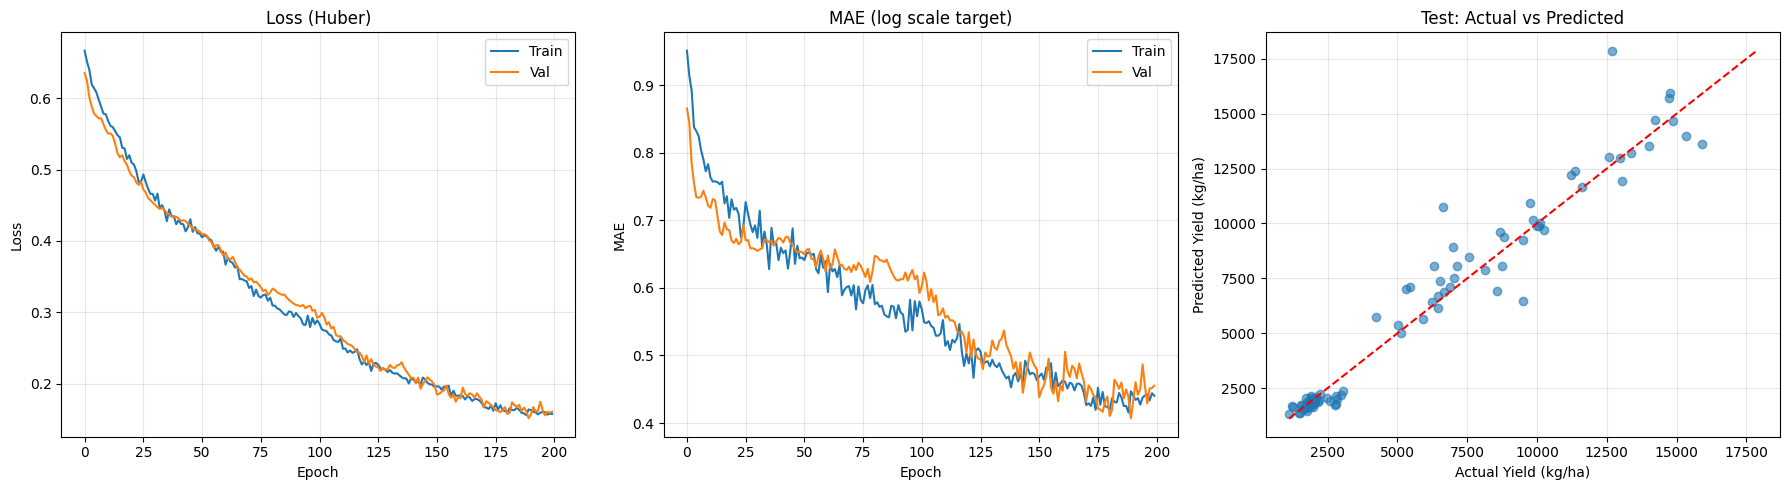

In [23]:
# Learning curves and test scatter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss (Huber)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train')
axes[1].plot(history.history['val_mae'], label='Val')
axes[1].set_title('MAE (log scale target)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].scatter(y_test_raw, yhat_test, alpha=0.6)
line_min = min(y_test_raw.min(), yhat_test.min())
line_max = max(y_test_raw.max(), yhat_test.max())
axes[2].plot([line_min, line_max], [line_min, line_max], 'r--')
axes[2].set_title('Test: Actual vs Predicted')
axes[2].set_xlabel('Actual Yield (kg/ha)')
axes[2].set_ylabel('Predicted Yield (kg/ha)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7) Save Artifacts

In [24]:
MODEL_PATH = '../models/TCN_MLP_9Feature_Lightweight.keras'
METRICS_PATH = '../results/TCN_MLP_9Feature_Lightweight_overall_metrics.csv'
REGION_PATH = '../results/TCN_MLP_9Feature_Lightweight_region_metrics.csv'
CROP_PATH = '../results/TCN_MLP_9Feature_Lightweight_crop_metrics.csv'
META_PATH = '../models/TCN_MLP_9Feature_Lightweight_metadata.json'

model.save(MODEL_PATH)
overall_metrics.to_csv(METRICS_PATH, index=False)
region_metrics.to_csv(REGION_PATH, index=False)
crop_metrics.to_csv(CROP_PATH, index=False)

meta = {
    'model_path': MODEL_PATH,
    'features': climate_features,
    'train_size': int(len(sub_train_idx)),
    'val_size': int(len(val_idx)),
    'test_size': int(len(test_idx)),
    'test_metrics': overall_metrics[overall_metrics['Split'] == 'Test'].to_dict(orient='records')[0]
}

with open(META_PATH, 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2)

print('Saved model:', MODEL_PATH)
print('Saved metrics:', METRICS_PATH)
print('Saved region metrics:', REGION_PATH)
print('Saved crop metrics:', CROP_PATH)
print('Saved metadata:', META_PATH)

Saved model: ../models/TCN_MLP_9Feature_Lightweight.keras
Saved metrics: ../results/TCN_MLP_9Feature_Lightweight_overall_metrics.csv
Saved region metrics: ../results/TCN_MLP_9Feature_Lightweight_region_metrics.csv
Saved crop metrics: ../results/TCN_MLP_9Feature_Lightweight_crop_metrics.csv
Saved metadata: ../models/TCN_MLP_9Feature_Lightweight_metadata.json
